In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.widgets import Slider
import h5py

%matplotlib widget

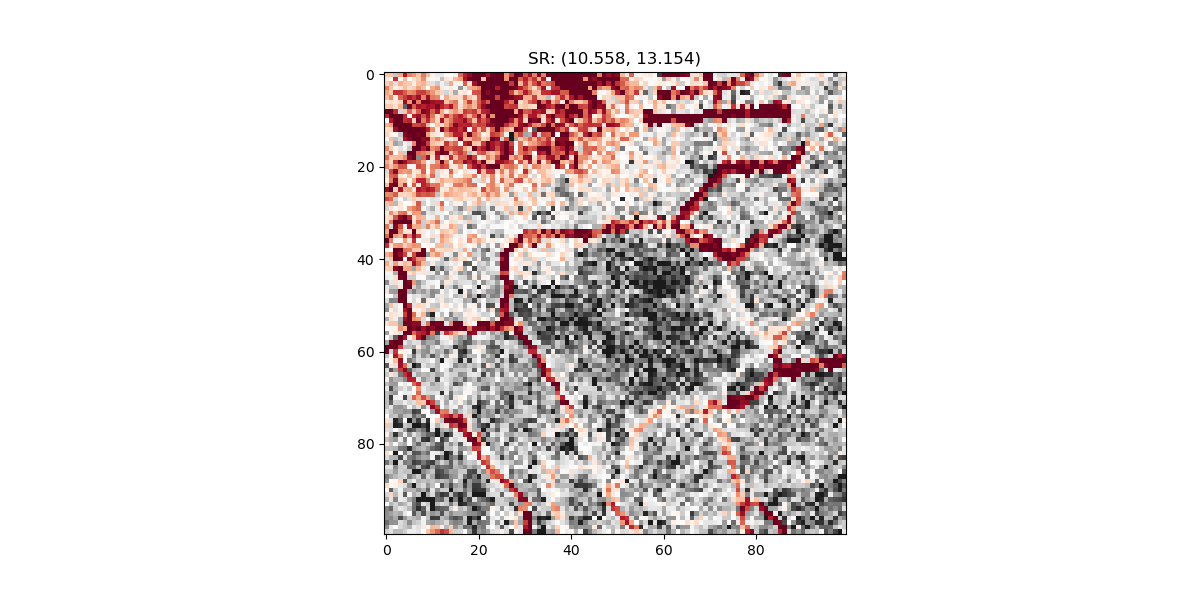

In [5]:
class InteractiveSlider:
    def __init__(self, stack, alphas=None, vmin=None, vmax=None, cmap="gray"):
        if alphas is None:
            alphas = np.ones(stack.shape[1:3])
        if vmin is None:
            vmin = np.min(stack)
        if vmax is None:
            vmax = np.max(stack)
        self.stack = stack
        self.vmin = vmin
        self.vmax = vmax
        self.alphas = alphas
        self.cmap = cmap
        plt.close(81234)
        self.fig = plt.figure(81234, figsize=(12, 8))
        self.ax = self.fig.add_subplot(111)
        self.ax.set_title("")
        # Show images
        self.im = self.ax.imshow(self.stack[0], alpha=self.alphas, vmin=self.vmin, vmax=self.vmax, cmap=self.cmap)
        # Put slider on
        plt.subplots_adjust(left=0.15, bottom=0.15)
        left = self.ax.get_position().x0
        bot = self.ax.get_position().y0
        height = self.ax.get_position().height
        axslice = plt.axes([left - 0.15, bot, 0.05, height])
        self.slice_slider = Slider(
            ax=axslice,
            label="Slice #",
            valmin=0,
            valmax=len(stack) - 1,
            valinit=0,
            valstep=1,
            orientation="vertical",
        )

        # Enable update functions
        self.slice_slider.on_changed(self.update_slice)
        plt.show()

    def update_slice(self, val):
        val = int(np.around(val, 0))
        image = self.stack[val]
        self.im.set_data(image)
        self.im.axes.figure.canvas.draw()
        self.fig.canvas.draw_idle()

sr = np.load(f"./output_data/TaAMSpall-Test_GND_SR.npy")

sr = np.log10(sr, where=sr > 0)

i = 50

plt.close("all")
fig, ax = plt.subplots(1, 1, figsize=(12, 6))
mn, mx = np.percentile(sr[sr > 0], (2.0, 95.0))
ax.set_title(f"SR: ({mn:.3f}, {mx:.3f})")
ax.imshow(sr[i], vmin=mn, vmax=mx, cmap="RdGy_r")
plt.show()

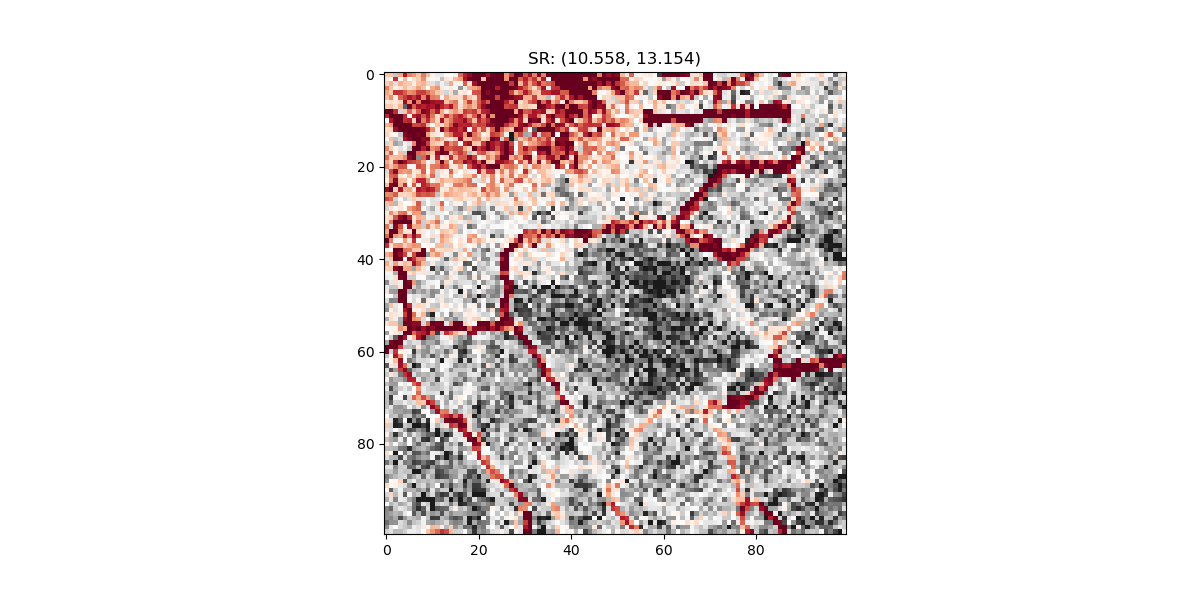

In [6]:

sr = np.load(f"./output_data/TaAMSpall-Test_GND_SR.npy")

sr = np.log10(sr, where=sr > 0)

i = 50

plt.close("all")
fig, ax = plt.subplots(1, 1, figsize=(12, 6))
mn, mx = np.percentile(sr[sr > 0], (2.0, 95.0))
ax.set_title(f"SR: ({mn:.3f}, {mx:.3f})")
ax.imshow(sr[i], vmin=mn, vmax=mx, cmap="RdGy_r")
plt.show()